In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv("pre_final_database.csv")
df.shape

(5529, 37)

In [3]:
df.head(5)

,catcher_id,jobma_catcher_title,jobma_catcher_otype,jobma_catcher_status,jobma_catcher_type,is_premium,jobma_verified,subscription_status,sub_user,per_sub_user,...,credit_given,currency_val,times_of_subscription,kits_count,position_created,number_of_invitations,pitchers_counts,def_interview_counts,interview_counts,ai_interview_counts
0,92,0,1,1,1,1,1,2,999,100,...,0,1.0,2,2.0,825.0,7.0,17640.0,3.0,2.0,0.0
1,106,0,1,-1,0,1,1,2,999,100,...,0,1.0,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,124,0,1,1,0,1,1,2,999,100,...,0,1.0,1,0.0,1.0,0.0,3.0,0.0,0.0,0.0
3,125,0,1,1,0,1,1,2,999,100,...,0,1.0,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,126,0,1,1,0,1,1,2,999,100,...,0,1.0,1,0.0,1.0,0.0,2.0,0.0,0.0,0.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5529 entries, 0 to 5528
Data columns (total 37 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   catcher_id                5529 non-null   int64  
 1   jobma_catcher_title       5529 non-null   int64  
 2   jobma_catcher_otype       5529 non-null   object 
 3   jobma_catcher_status      5529 non-null   int64  
 4   jobma_catcher_type        5529 non-null   int64  
 5   is_premium                5529 non-null   int64  
 6   jobma_verified            5529 non-null   int64  
 7   subscription_status       5529 non-null   int64  
 8   sub_user                  5529 non-null   int64  
 9   per_sub_user              5529 non-null   object 
 10  live_interview_credit     5529 non-null   float64
 11  pre_recorded_credit       5529 non-null   float64
 12  ai_live_interview_credit  5529 non-null   float64
 13  interview_cost_type       5529 non-null   int64  
 14  referral

In [5]:
df.isnull().sum().sum()

np.int64(0)

In [6]:
df.nunique()

catcher_id                  5529
jobma_catcher_title            9
jobma_catcher_otype            7
jobma_catcher_status           3
jobma_catcher_type             2
is_premium                     2
jobma_verified                 2
subscription_status            3
sub_user                      62
per_sub_user                   9
live_interview_credit         22
pre_recorded_credit           29
ai_live_interview_credit       2
interview_cost_type            2
referral_credit                6
company_size                   5
ai_live_interview              2
days_since_creation         1078
confirmed                      2
number_of_logins               6
credit_amount                 39
wallet_amount                714
plan_type                      2
is_unlimited                   2
trial_account_type             2
billing_cycle_status           2
subscription_amount          222
credit_given                  29
currency_val                  39
times_of_subscription         37
kits_count

In [7]:
# df['company_size'] = pd.Categorical(df['company_size'], categories=['1-25', '26-100', '101-500', '500-1000', 'More than 1000'], ordered=True).codes
# df = pd.get_dummies(df, columns=['jobma_catcher_otype', 'per_sub_user'], prefix=['otype', 'subuser'], drop_first=True)

# df = df.astype({col: int for col in df.columns if df[col].dtype == 'bool'})
# df['sub_user'] = df['sub_user'].apply(lambda x: 1000 if x > 1000 else x)      #To handele outlier

In [8]:
df.describe()

,catcher_id,jobma_catcher_title,jobma_catcher_status,jobma_catcher_type,is_premium,jobma_verified,subscription_status,sub_user,live_interview_credit,pre_recorded_credit,...,credit_given,currency_val,times_of_subscription,kits_count,position_created,number_of_invitations,pitchers_counts,def_interview_counts,interview_counts,ai_interview_counts
count,5529.000000,5529.000000,5529.000000,5529.000000,5529.000000,5529.000000,5529.000000,5529.000000,5529.000000,5529.000000,...,5529.000000,5529.000000,5529.000000,5529.000000,5529.000000,5529.000000,5529.000000,5529.000000,5529.000000,5529.000000
mean,4768.240369,0.234943,0.908663,0.922590,0.378188,0.999096,1.887864,279.376379,1.423505,3.383758,...,49.328269,1.977976,1.986616,2.605173,1.512751,8.709893,6.570266,3.347260,0.170194,0.013384
std,2431.388564,0.777744,0.301610,0.267265,0.484979,0.030061,0.317847,1927.332416,13.675515,135.205973,...,291.776292,8.306666,4.597021,128.021540,18.617189,102.554300,240.300559,37.065864,3.278246,0.903944
min,92.000000,0.000000,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2774.000000,0.000000,1.000000,1.000000,0.000000,1.000000,2.000000,1.000000,1.000000,1.000000,...,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,4794.000000,0.000000,1.000000,1.000000,0.000000,1.000000,2.000000,5.000000,1.000000,1.000000,...,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,6914.000000,0.000000,1.000000,1.000000,1.000000,1.000000,2.000000,103.000000,1.000000,1.000000,...,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,9445.000000,8.000000,1.000000,1.000000,1.000000,1.000000,2.000000,140000.000000,1000.000000,9999.990000,...,10000.000000,71.870000,238.000000,9504.000000,825.000000,3396.000000,17640.000000,1069.000000,150.000000,67.000000


In [9]:
pd.set_option('display.float_format', '{:.2f}'.format)
df.describe().T

,count,mean,std,min,25%,50%,75%,max
catcher_id,5529.00,4768.24,2431.39,92.00,2774.00,4794.00,6914.00,9445.00
jobma_catcher_title,5529.00,0.23,0.78,0.00,0.00,0.00,0.00,8.00
jobma_catcher_status,5529.00,0.91,0.30,-1.00,1.00,1.00,1.00,1.00
jobma_catcher_type,5529.00,0.92,0.27,0.00,1.00,1.00,1.00,1.00
is_premium,5529.00,0.38,0.48,0.00,0.00,0.00,1.00,1.00
jobma_verified,5529.00,1.00,0.03,0.00,1.00,1.00,1.00,1.00
subscription_status,5529.00,1.89,0.32,0.00,2.00,2.00,2.00,2.00
sub_user,5529.00,279.38,1927.33,0.00,1.00,5.00,103.00,140000.00
live_interview_credit,5529.00,1.42,13.68,0.00,1.00,1.00,1.00,1000.00
pre_recorded_credit,5529.00,3.38,135.21,0.00,1.00,1.00,1.00,9999.99


In [10]:
df['wallet_amount'] = df['wallet_amount'].astype(int)

In [11]:
df['sub_user'].value_counts().head(50)

sub_user
1       2074
999     1356
10       872
2        264
100      200
0        183
3        140
4         83
5         69
11        49
6         25
60        23
12        22
13        16
14        15
15        11
7         11
9         11
22         8
16         7
20         7
1000       5
8          5
26         5
21         5
1009       4
18         4
110        4
17         4
103        3
27         3
101        3
50         2
30         2
62         2
102        2
31         2
66         2
61         2
106        2
40         1
109        1
37         1
123        1
35         1
130        1
64         1
63         1
65         1
145        1
Name: count, dtype: int64

In [12]:
df['sub_user'].unique()

array([   999,     37,     10,      7,      1,      3,    109,     12,
            4,     22,      5,      2,      6,     11,     35,     13,
            9,     15,     17,     31,     14,    102,    123,   1000,
            0,    101,    100,    103,     40,     16,      8,    120,
          107,    106,     26,    130,    145,     61,     60,     65,
           63,     18,     64,     62,     66,     30,     21, 140000,
          113,     19,    116,     20,   1009,     27,    110,     24,
           29,     73,     53,     23,   1001,     50])

<Axes: xlabel='sub_user'>

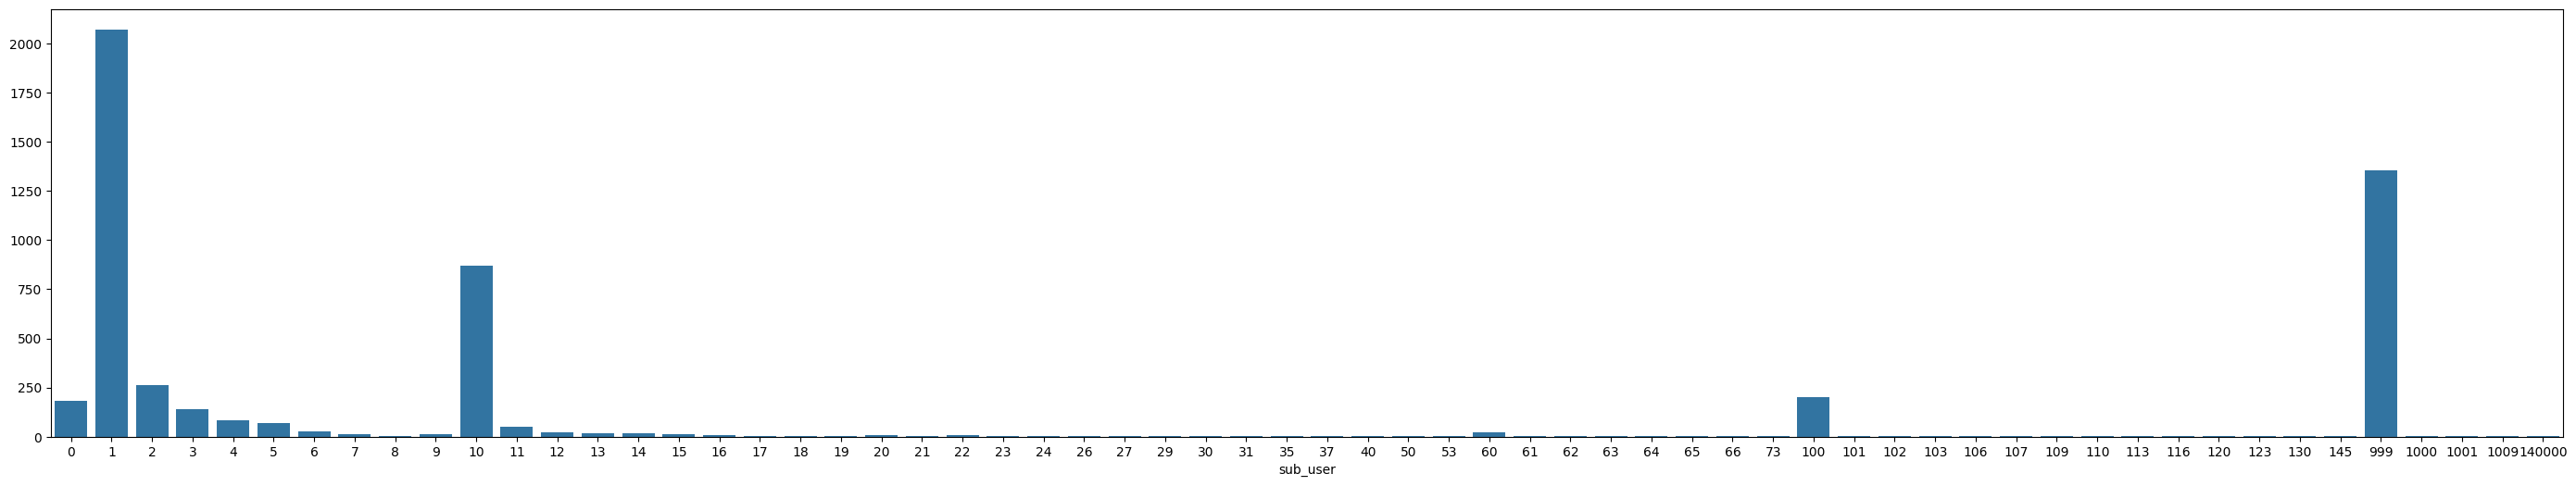

In [13]:
sub_user_counts = df['sub_user'].value_counts()
plt.figure(figsize=(35, 6))
sns.barplot(x=sub_user_counts.index, y=sub_user_counts.values)

<Axes: xlabel='sub_user', ylabel='count'>

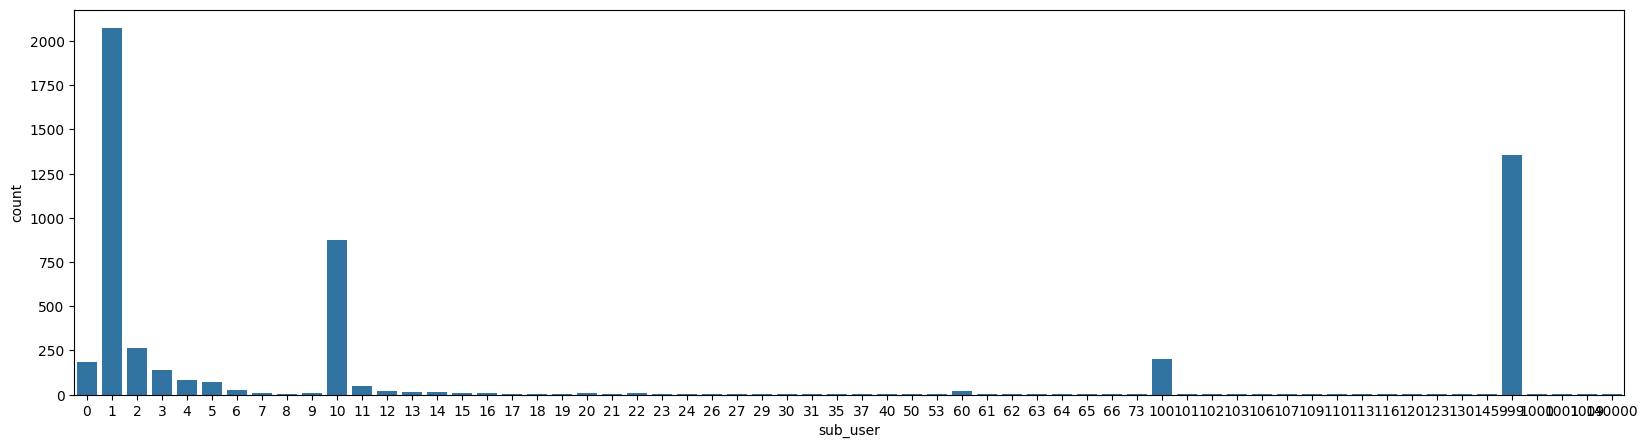

In [14]:
plt.figure(figsize=(20,5))
sns.countplot(x=df['sub_user'])

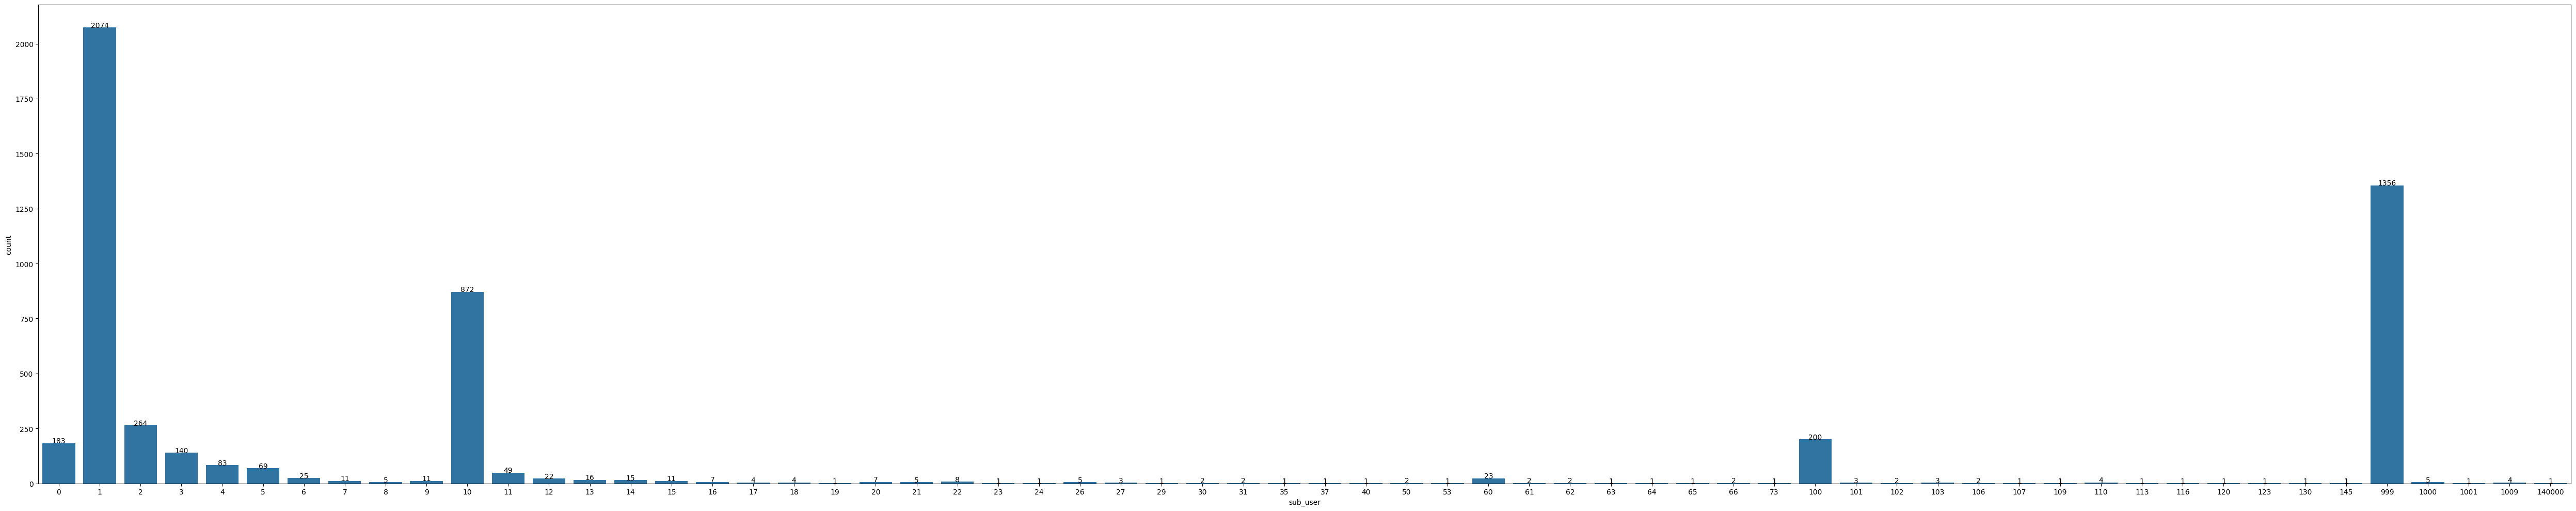

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(50, 10))
ax = sns.countplot(x=df['sub_user'])

# Add text labels above bars
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width() / 2., height + 1, f'{int(height)}', ha='center')

plt.tight_layout()
plt.show()


<Axes: xlabel='sub_user'>

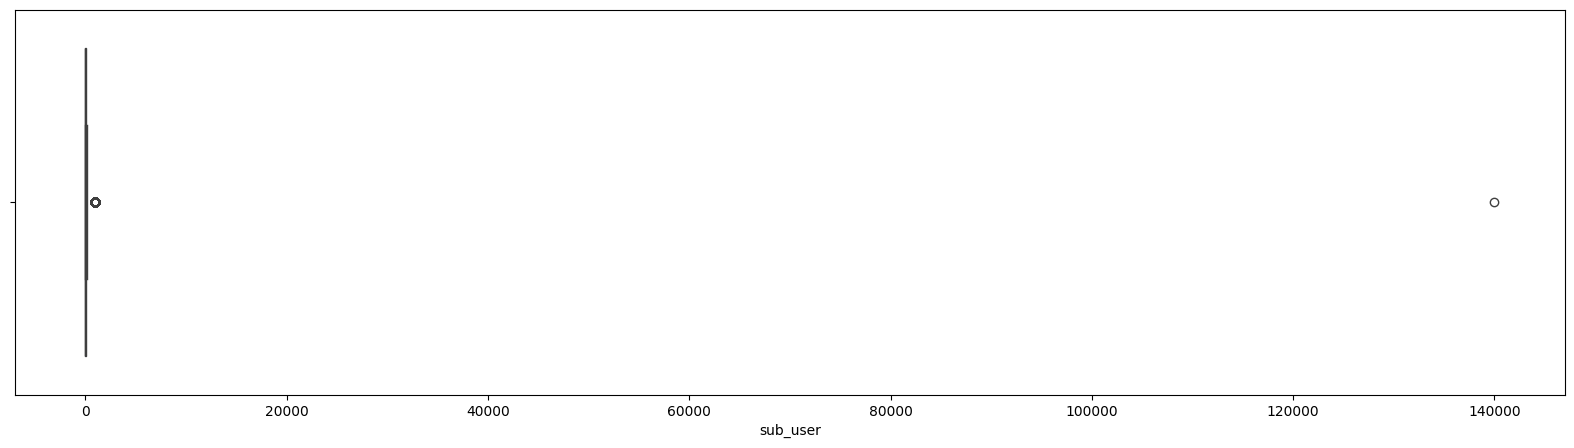

In [16]:
plt.figure(figsize=(20,5))
sns.boxplot(x=df['sub_user'])

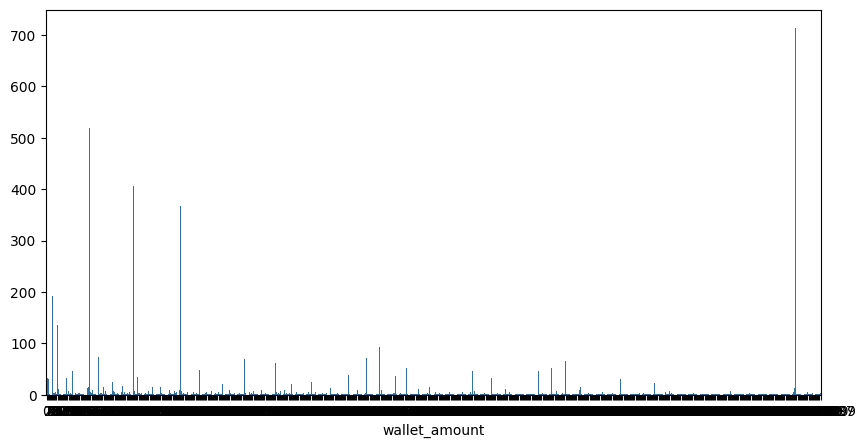

In [17]:
wallet_counts = df['wallet_amount'].value_counts().sort_index()
plt.figure(figsize=(10,5))
sns.barplot(x=wallet_counts.index, y=wallet_counts.values)
plt.show()

<Axes: xlabel='wallet_amount', ylabel='Count'>

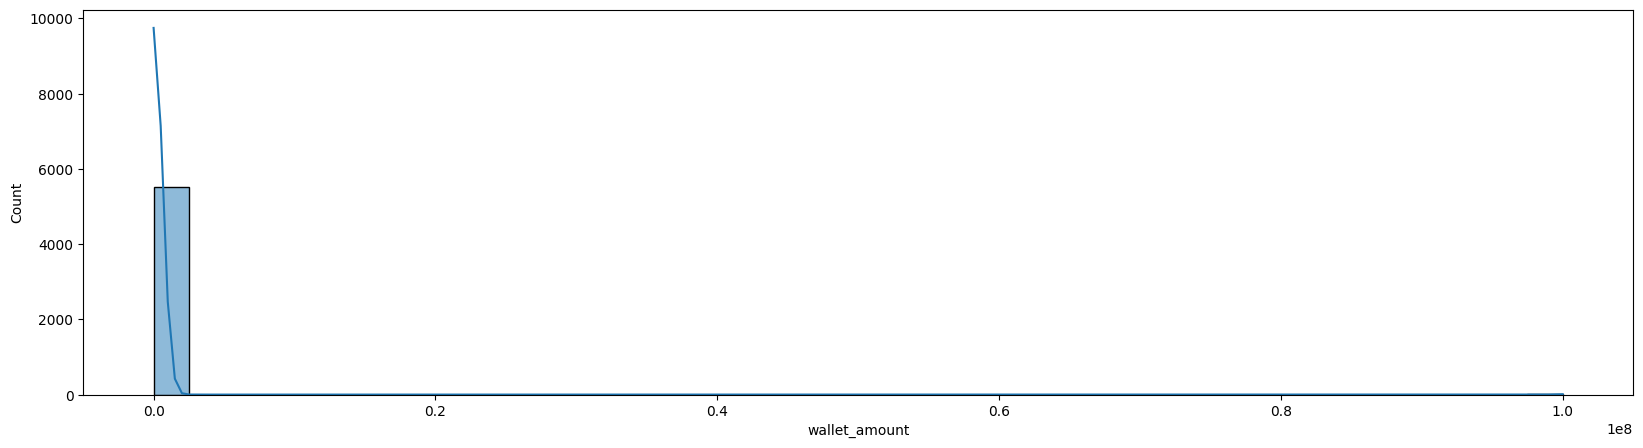

In [18]:
plt.figure(figsize=(20,5))
sns.histplot(df['wallet_amount'], bins=40, kde=True)

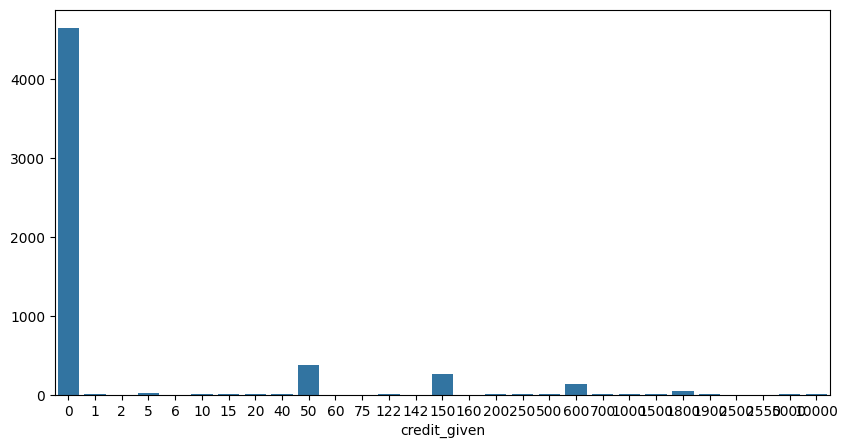

In [19]:
wallet_counts = df['credit_given'].value_counts().sort_index()
plt.figure(figsize=(10,5))
sns.barplot(x=wallet_counts.index, y=wallet_counts.values)
plt.show()


In [20]:
df['credit_given'].nunique()

29

In [21]:
# #unique values
# print("Unique values in column:")
# for col in range(6, 36):  # Columns from index 4 to 24
#     print(f"{df.columns[col]}: {df[df.columns[col]].unique()} \n")



# print("Unique values in column:")
# for col in range(2, 37):
#     unique_values = df[df.columns[col]].unique()
#     print(f"{df.columns[col]}:")
#     if len(unique_values) > 10:
#         continue
#     else:
#         print(unique_values, "\n")


In [22]:
df['sub_user'].value_counts().head(50)

sub_user
1       2074
999     1356
10       872
2        264
100      200
0        183
3        140
4         83
5         69
11        49
6         25
60        23
12        22
13        16
14        15
15        11
7         11
9         11
22         8
16         7
20         7
1000       5
8          5
26         5
21         5
1009       4
18         4
110        4
17         4
103        3
27         3
101        3
50         2
30         2
62         2
102        2
31         2
66         2
61         2
106        2
40         1
109        1
37         1
123        1
35         1
130        1
64         1
63         1
65         1
145        1
Name: count, dtype: int64

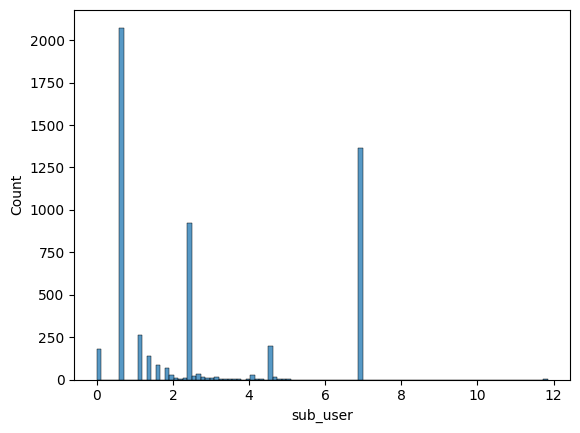

In [23]:
sns.histplot(np.log1p(df['sub_user']), bins=100)
plt.ylabel('Count')
plt.show()


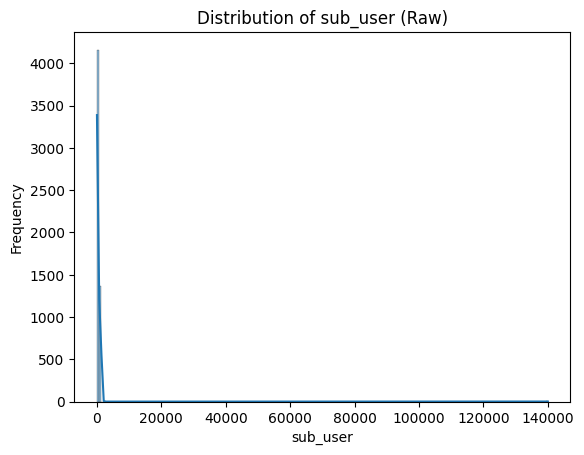

In [24]:
sns.histplot(df['sub_user'], bins=200, kde=True)
plt.title("Distribution of sub_user (Raw)")
plt.xlabel("sub_user")
plt.ylabel("Frequency")
plt.show()


<Axes: xlabel='sub_user'>

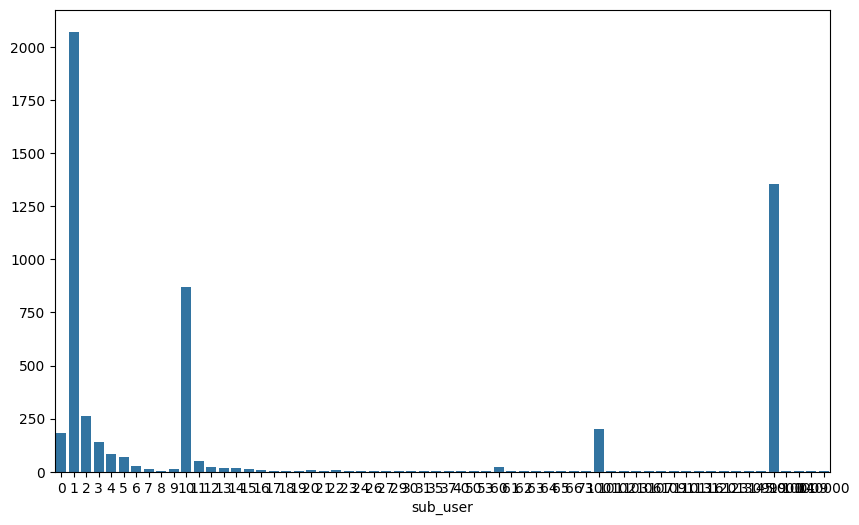

In [25]:
sub_user_counts = df['sub_user'].value_counts()
plt.figure(figsize=(10, 6))
sns.barplot(x=sub_user_counts.index, y=sub_user_counts.values)

In [26]:
df['pre_recorded_credit'].nunique()

29

In [27]:
df['pre_recorded_credit'].value_counts()

pre_recorded_credit
1.00       5020
0.00        185
1.50        125
15.00        63
2.00         37
1.33         20
3.00         19
16.00         9
0.10          7
50.00         6
5.00          6
10.00         6
0.67          4
30.00         3
100.00        3
4.00          3
85.00         1
1.75          1
1.22          1
0.86          1
0.50          1
1000.00       1
11.00         1
60.00         1
150.00        1
120.00        1
9999.99       1
20.00         1
9.00          1
Name: count, dtype: int64

<Axes: ylabel='pre_recorded_credit'>

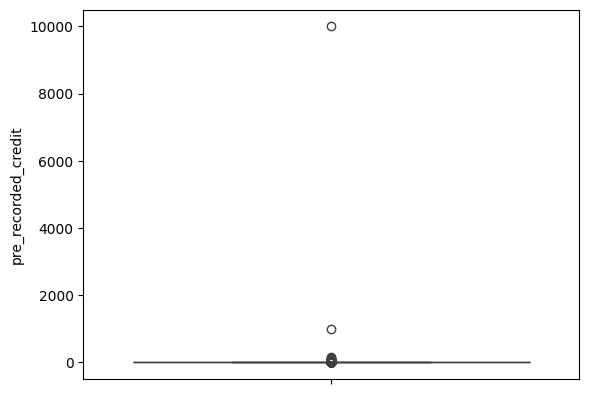

In [28]:
sns.boxplot(df['pre_recorded_credit'])

<Axes: xlabel='pre_recorded_credit', ylabel='Count'>

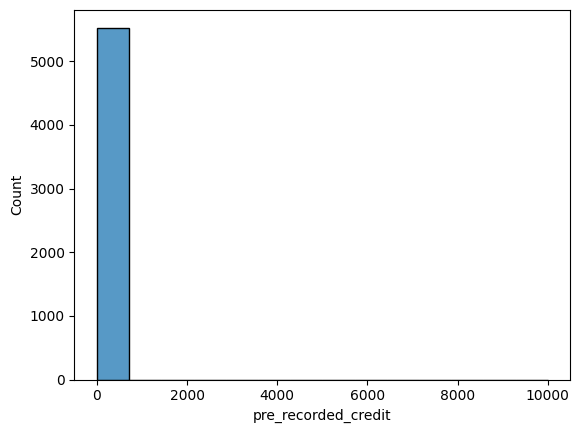

In [29]:
sns.histplot(df['pre_recorded_credit'])

<Axes: >

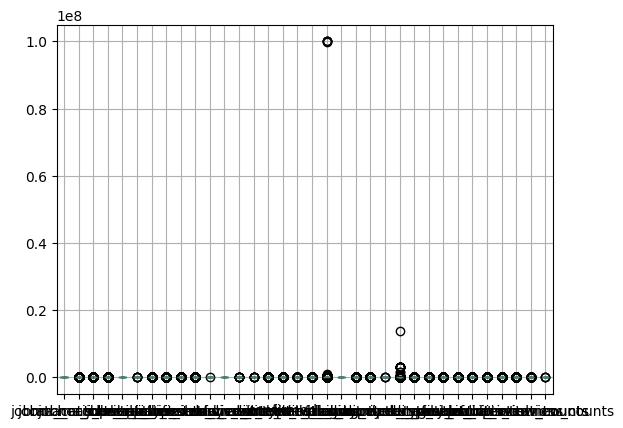

In [30]:
df.boxplot()

In [31]:
df.T

,0,1,2,3,4,5,6,7,8,9,...,5519,5520,5521,5522,5523,5524,5525,5526,5527,5528
catcher_id,92,106,124,125,126,127,128,129,130,131,...,9297,9299,9311,9313,9315,9319,9365,9405,9413,9445
jobma_catcher_title,0,0,0,0,0,0,0,0,0,0,...,0,1,1,0,1,4,0,1,0,1
jobma_catcher_otype,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
jobma_catcher_status,1,-1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
jobma_catcher_type,1,0,0,0,0,0,0,0,0,0,...,1,1,1,1,1,1,1,1,1,1
is_premium,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,1,0,0,0
jobma_verified,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
subscription_status,2,2,2,2,2,2,2,2,2,2,...,1,1,1,1,1,1,1,1,1,1
sub_user,999,999,999,999,999,999,999,999,999,999,...,999,1,10,1,999,999,21,999,10,10
per_sub_user,100,100,100,100,100,100,100,100,100,100,...,100,100,100,100,100,100,100,100,100,100
